#### Data Story - Median Cost per watt as a function of time and customer type.

3) Now loading data20180105 after d_q_and_c_5.  Has extra integer field unique_id.  Removed all nulls and zero vals in cost, cpw, size_kw.

2) Revisit with cleaned up install_type from d_q_and_c_install_type.  Consolidated install_type is now i_type.

1) Before I do this I need to clean residential data.  Maybe I should look at commercial data and see if it needs it too...

In [1]:
# %load ../pycode/setup.py
# set up
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

%matplotlib inline

def ecdf(data):
    '''Compute ECDF for a one-dimensional array of measurements.'''
    n = len(data)
    x = np.sort(data)
    y = np.arange(1, n + 1) / n
    return x, y

def min015099max(series):
    ''' return list of [ min, 1%, median, 99%, max ] series values '''
    vals = list(np.percentile(series, [1.0, 50.0, 99.0]))
    vals.insert(-1, series.max())
    vals.insert(0, series.min())
    return vals

# ss = np.arange(1, 101)
# min_1_50_99_max(ss)             

def mid98(series):
    '''  return middle 98% of series '''
    bounds = series.quantile([0.01, 0.99])
    return(series[(series > bounds.values[0]) & (series < bounds.values[1])])

# ss = np.arange(1, 101)
# min_1_50_99_max(ss)


In [2]:
# load more concise dataset for exploration
#dfLive = pd.read_csv('../local/data/20180105', index_col='date_installed', parse_dates=True)
dfLive = pd.read_csv('../local/data/thing0108', index_col='date_installed', parse_dates=True)

In [3]:
dfLive.describe()

,row_id,cost_per_watt,cost,size_kw,zipcode,new_constr,tracking,third_party,bipv
count,416204.000000,416204.000000,4.162040e+05,416204.000000,416204.000000,5038.0,1092.0,112078.0,871.0
mean,389759.045350,5.644024,6.846463e+04,13.516131,67881.520754,1.0,1.0,1.0,1.0
std,218126.031578,2.092055,5.308133e+05,120.615689,37258.626800,0.0,0.0,0.0,0.0
min,1.000000,0.750000,1.000000e+02,0.010000,206.000000,1.0,1.0,1.0,1.0
25%,194379.500000,4.250000,2.151038e+04,4.080000,19465.000000,1.0,1.0,1.0,1.0
50%,414091.500000,5.250000,3.060000e+04,5.890000,91342.000000,1.0,1.0,1.0,1.0
75%,579745.250000,6.840000,4.412500e+04,8.400000,93308.000000,1.0,1.0,1.0,1.0
max,745361.000000,30.000000,1.522000e+08,27600.000000,99737.000000,1.0,1.0,1.0,1.0


In [4]:
dfLive.describe(include=np.object)

,state,city,county,appraised,incentive,utility,tech,model,installer,i_type
count,416204,286405,408536,42906,285731,283837,216537,216537,235939,416204
unique,52,8587,866,1,51,287,11,2712,6060,8
top,CA,TUCSON,Los Angeles,True,California Public Utilities Commission (Non-CS...,Southern California Edison,Poly,multiple matches,SolarCity,residential
freq,227866,4592,35107,42906,57504,53882,117472,35589,29525,383609


In [5]:
dfLive.head()

,row_id,cost_per_watt,cost,size_kw,state,zipcode,city,county,new_constr,tracking,third_party,appraised,incentive,utility,tech,model,installer,bipv,i_type
date_installed,,,,,,,,,,,,,,,,,,,
2004-01-01,1,5.74,195000.00,34.00,MN,55407,NaN,Hennepin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,commercial
2004-01-02,18,10.32,15238.09,1.48,MA,1340,Colrain,Franklin,NaN,1.0,NaN,NaN,Massachusetts Clean Energy Center,WMECO (DBA EverSource),NaN,NaN,Pv Squared,NaN,residential
2004-01-05,19,6.62,18278.00,2.76,MA,2451,NaN,Middlesex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residential
2004-01-05,20,6.00,34000.00,5.67,MA,2770,NaN,Plymouth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residential
2004-01-06,24,7.89,32120.00,4.07,NY,11231,Brooklyn,Kings,NaN,NaN,NaN,NaN,New York State Energy Research and Development...,Consolidated Edison,Mono,multiple matches,NaN,NaN,residential


In [6]:
dfLive.tail()

,row_id,cost_per_watt,cost,size_kw,state,zipcode,city,county,new_constr,tracking,third_party,appraised,incentive,utility,tech,model,installer,bipv,i_type
date_installed,,,,,,,,,,,,,,,,,,,
2015-12-31,745356,5.80,15667.0,2.70,CA,93291,Visalia,Tulare,NaN,NaN,1.0,True,California Public Utilities Commission (Non-CS...,Southern California Edison,Poly,multiple matches,SolarCity,NaN,residential
2015-12-31,745357,5.77,15974.4,2.77,CA,93291,Visalia,Tulare,NaN,NaN,1.0,True,California Public Utilities Commission (Non-CS...,Southern California Edison,Poly,REC260PE Z-LINK,SolarCity,NaN,residential
2015-12-31,745358,4.20,54600.0,13.00,CA,92065,RAMONA,San Diego,NaN,NaN,NaN,NaN,California Public Utilities Commission (Non-CS...,San Diego Gas & Electric Company,Poly,CS6P-260P,Solar West Electric,NaN,residential
2015-12-31,745359,4.20,49442.0,11.77,CA,92065,RAMONA,San Diego,NaN,NaN,1.0,NaN,California Public Utilities Commission (Non-CS...,San Diego Gas & Electric Company,Mono,SPR-327NE-WHT-D,Pacific Sky Solar,NaN,residential
2015-12-31,745361,3.48,19710.0,5.67,CA,92056,OCEANSIDE,San Diego,NaN,1.0,NaN,NaN,California Public Utilities Commission (Non-CS...,San Diego Gas & Electric Company,Mono,LG315N1C-G4,Natural Energy,NaN,residential


In [7]:
# any nulls in the index (once bitten...)
dfLive.index.isnull().sum()

0

In [8]:
# show me the fields
dfLive.columns

Index(['row_id', 'cost_per_watt', 'cost', 'size_kw', 'state', 'zipcode',
       'city', 'county', 'new_constr', 'tracking', 'third_party', 'appraised',
       'incentive', 'utility', 'tech', 'model', 'installer', 'bipv', 'i_type'],
      dtype='object')

In [9]:
# don't have this column in this input file
# any nulls in row_id
# dfLive['Unnamed: 0'].isnull().sum()

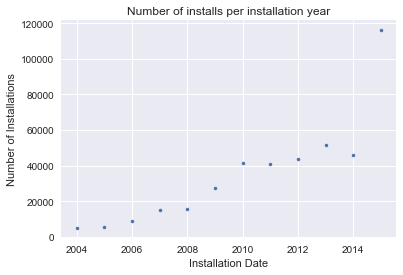

In [10]:
# check to see if it's what I think
# this has definitely changed after cleaning; there isn't a drop in installs in 13 and 14
# just lots of not so great data those years
dfLive.groupby(dfLive.index.year).size().plot(marker='.', linestyle='none')
plt.title('Number of installs per installation year')
plt.ylabel('Number of Installations')
plt.xlabel('Installation Date');

In [11]:
dfRes = dfLive.loc[dfLive.i_type == 'residential']

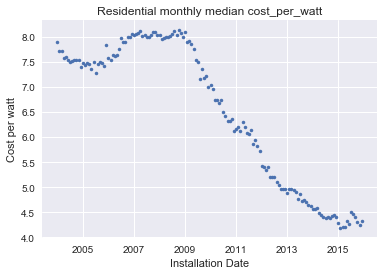

In [12]:
dfRes.resample('M')['cost_per_watt'].median().plot(marker='.', linestyle='none')
plt.title('Residential monthly median cost_per_watt')
plt.ylabel('Cost per watt')
plt.xlabel('Installation Date');

In [13]:
# this is starting to look a lot like what I need
# we needed to have a df to work with.
# dfLive.groupby(['install_type', dfLive.index.year, dfLive.index.month])['cost_per_watt'].median()
# delivers a series.  That's fine, but we need df methods to change the shape into the right form.
typeYearMonth = pd.DataFrame(dfLive.groupby(['i_type', dfLive.index.year, dfLive.index.month])['cost_per_watt'].median())
typeYearMonth.head()

cost_per_watt
i_type       date_installed date_installed               
agricultural 2004           4                        5.89
                            8                        7.60
             2006           5                        7.22
                            6                        6.84
                            10                       5.95

In [14]:
typeYearMonth.loc['residential'].head()

cost_per_watt
date_installed date_installed               
2004           1                        7.89
               2                        7.71
               3                        7.71
               4                        7.57
               5                        7.59

In [15]:
# okay, what I want to do is pivot the type into the columns
type(typeYearMonth)

pandas.core.frame.DataFrame

In [16]:
# year, Month in rows - cost_per_watt, i_type in columns
yearMonth_cpwType = typeYearMonth.unstack('i_type'); yearMonth_cpwType.head(15)

cost_per_watt                                    \
i_type                         agricultural commercial educational government   
date_installed date_installed                                                   
2004           1                        NaN      6.590       9.360        NaN   
               2                        NaN      7.410         NaN      8.810   
               3                        NaN      8.020       7.860        NaN   
               4                       5.89      7.220      10.000        NaN   
               5                        NaN      7.830       8.560      6.310   
               6                        NaN      6.930       7.525      6.410   
               7                        NaN      7.480         NaN        NaN   
               8                       7.60      7.790       8.655     15.900   
               9                        NaN      7.870      12.000      9.880   
               10                       NaN      7.980       7.380      9.705   
               11                       NaN      7.510         NaN        NaN   
               12                       NaN      7.140       9.830     19.000   
2005           1                        NaN      7.910         NaN      7.245   
               2                        NaN      7.290       8.530        NaN   
               3                        NaN      7.465       6.895      9.890   

                                                                     
i_type                        nonprofit residential unknown utility  
date_installed date_installed                                        
2004           1                  7.620       7.890     NaN     NaN  
               2                 13.810       7.710  13.810     NaN  
               3                    NaN       7.710   7.690     NaN  
               4                  7.270       7.570   7.570     NaN  
               5                 21.980       7.590   4.070     NaN  
               6                  6.450       7.530   8.485     NaN  
               7                  8.270       7.495   8.480     NaN  
               8                  7.960       7.520     NaN     NaN  
               9                 10.100       7.530   8.005     NaN  
               10                   NaN       7.530   7.655     NaN  
               11                   NaN       7.540   7.820     NaN  
               12                 7.490       7.400   5.970     NaN  
2005           1                 11.630       7.480   8.280     NaN  
               2                  8.125       7.440   9.180     NaN  
               3                  3.270       7.470   8.060     NaN

In [17]:
# the values of the index are tuples. first element is year(int), 2nd is month(int)
yearMonth_cpwType.index.get_values()[:10]

array([(2004, 1), (2004, 2), (2004, 3), (2004, 4), (2004, 5), (2004, 6),
       (2004, 7), (2004, 8), (2004, 9), (2004, 10)], dtype=object)

In [18]:
def yearMonthTup_to_datetime(tup):
    ''' Takes a tuple of the form (year(int), month(int)); returns datetime for first of that month'''
    str = '{}{:02d}{}'.format(tup[0], tup[1], '01')
    return pd.to_datetime(str)

In [19]:
yearMonthTup_to_datetime((2004, 1))

Timestamp('2004-01-01 00:00:00')

In [20]:
# now I need to fix the index so that I can use it for plotting
# maybe just make a new column that's a datetime with year and month from existing index
dtYearMonth = yearMonth_cpwType.index.map(yearMonthTup_to_datetime)

In [21]:
# nice
dtYearMonth[:10]

DatetimeIndex(['2004-01-01', '2004-02-01', '2004-03-01', '2004-04-01',
               '2004-05-01', '2004-06-01', '2004-07-01', '2004-08-01',
               '2004-09-01', '2004-10-01'],
              dtype='datetime64[ns]', freq=None)

In [22]:
dt_cpwType = yearMonth_cpwType.set_index(dtYearMonth)

In [23]:
dt_cpwType.head()

cost_per_watt                                              \
i_type      agricultural commercial educational government nonprofit   
2004-01-01           NaN       6.59        9.36        NaN      7.62   
2004-02-01           NaN       7.41         NaN       8.81     13.81   
2004-03-01           NaN       8.02        7.86        NaN       NaN   
2004-04-01          5.89       7.22       10.00        NaN      7.27   
2004-05-01           NaN       7.83        8.56       6.31     21.98   

                                        
i_type     residential unknown utility  
2004-01-01        7.89     NaN     NaN  
2004-02-01        7.71   13.81     NaN  
2004-03-01        7.71    7.69     NaN  
2004-04-01        7.57    7.57     NaN  
2004-05-01        7.59    4.07     NaN

In [24]:
plt.rc('figure', figsize=(10, 6))

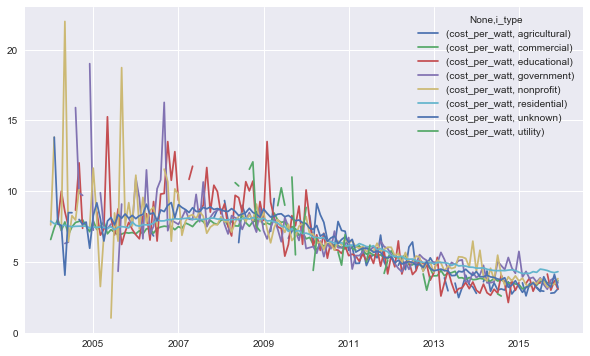

In [25]:
dt_cpwType.plot()

In [26]:
dt_cpwType.columns

MultiIndex(levels=[['cost_per_watt'], ['agricultural', 'commercial', 'educational', 'government', 'nonprofit', 'residential', 'unknown', 'utility']],
           labels=[[0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 2, 3, 4, 5, 6, 7]],
           names=[None, 'i_type'])

In [27]:
# so how do I get to my columns in this multi-index
dt_cpwType.loc[:, (slice(None), ['residential', 'commercial', 'unknown', 
                    'government', 'nonprofit', 'educational'] )].head()

cost_per_watt                                                     
i_type        commercial educational government nonprofit residential unknown
2004-01-01          6.59        9.36        NaN      7.62        7.89     NaN
2004-02-01          7.41         NaN       8.81     13.81        7.71   13.81
2004-03-01          8.02        7.86        NaN       NaN        7.71    7.69
2004-04-01          7.22       10.00        NaN      7.27        7.57    7.57
2004-05-01          7.83        8.56       6.31     21.98        7.59    4.07

In [28]:
dt_cpwType.loc[:, (slice(None), ['residential', 'commercial', 'unknown', 
                    'government', 'nonprofit', 'educational'])].tail()

cost_per_watt                                                     
i_type        commercial educational government nonprofit residential unknown
2015-08-01         3.690         NaN      3.410     3.620        4.46   3.960
2015-09-01         3.540       4.150      3.080     3.225        4.40   3.440
2015-10-01         3.495       3.015      3.735     3.405        4.30   3.225
2015-11-01         3.470       3.670      3.880     3.430        4.25   4.125
2015-12-01         3.670       3.080      3.530     3.830        4.32   3.210

In [29]:
# what are the value_counts again?  I may want to leave out the ones with not many installations.
dfLive.i_type.value_counts()

residential     383609
commercial       15795
unknown          10085
government        3185
nonprofit         2251
educational       1011
agricultural       209
utility             59
Name: i_type, dtype: int64

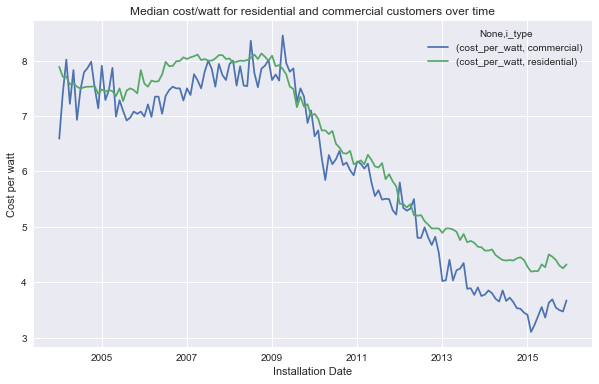

In [30]:
dt_cpwType.loc[:, (slice(None), ['residential', 'commercial'])].plot() 
# marker='.', linestyle='none'
plt.title('Median cost/watt for residential and commercial customers over time')
plt.xlabel('Installation Date')
plt.ylabel('Cost per watt');

### What does this chart and the one above tell us?

It says:

1. cost per watt declines for all installations from 2005 to 2015.
1. cost per watt converges for all kind of customers from 2005  to 2015
2. residential customers pay more per watt than commercial customers.

#### What questions does this raise?

1. it that strictly a function of size.  
2. are commercial installations generally larger than residential installations?
3. does that vary with time?
4. what is the distribution of size by i_type?  does that vary over time?
